# <font color = "#9932CC">**Trabalho 03 - Grafos e Redes Sociais**
### **Pontifícia Universidade Católica de Campinas**
### **Prof. Fernando Soares de Aguiar Neto**
### **Integrantes**
- Francisco da Silva Bueno Junior - 25008051
- Isabel Baungartner - 25001436
- Julia de Souza Leandro - 25009148
- Tiago Noda Von Zuben - 25018493




---



### **📝 Descrição do Trabalho**

**❗Requisitos:**


- Questões de Pesquisa **(2 pts cada)**
- Plots com distribuições de métricas em relação à quantidade de vértices/arestas **(1pt)**
- Gráficos de comparação do grafo escolhido na parte 2 com seus paralelos sintéticos **(0.5pt)**
- Responder se Grafo da Parte 2 parece livre de escala, small world ou aleatório **(0.5pt)**
- Mostrar vértices mais importantes e motivar a resposta **(1pt)**
-Responder outras perguntas da Parte 2 **(1pt)**

**❗Análise Geral:**

Usando grafos gerados sinteticamente *(Barabasi-Albert, Watts-Strogatz, e Erdös-Renyi)*, devem extrair dados das medidas discutidas em aula. Lembrando que algumas medidas podem levar muito tempo, programem para que o processo seja eficiente e factível.

<br>

Devem ser avaliadas o máximo de medidas vistas em aula, algumas medidas como diâmetro ou distribuição de shortest path podem ficar lentas de mais para grafos grandes, façam o máximo possível
<br><br>

Façam vários grafos com as mesmas propriedades, mas variando seed, isso evita um viés amostral na hora de gerar os grafos
<br><br>

Não quero apenas uma descrição das medidas obtidas, façam questões de pesquisa e mostrem evidências à favor ou contra, e.g.:

- Há correlação entre probabilidade de conexão e clustering coefficient global? `Acreditamos que sim pois .... (<mostrar evidências e discutir>)`

- Redes livres de escala tendem a ser assortativas? `Acreditamos que não pois ... (<mostrar evidências e discutir>)`

- Há alguma correlação entre tal e tal métricas? `Acreditamos (...) (<mostrar evidências e discutir>)`

`Acreditamos que tal métrica depende do grau médio apenas em redes tal. (...) (<mostrar evidências e discutir>)`
<br><br>

Quero ao menos 3 questões do tipo com suas devidas análises, fora um plot geral com a distribuição das métricas para diferentes configurações de grafos



---



**❗Comparação com o grafo:**

1. Selecionem um grafo suficientemente grande *(ao menos 300 vértices)* de um dos repositórios já disponibilizados em aula

2. Comparem ele com as versões sintéticas equivalentes
Respondam com evidências: ele parece ser livre de escala, small world ou aleatório? Expliquem.

3. Respondam também:
- Quais os 3 vértices mais importantes desse grafo e o porquê?
- Essa rede tende a ser robusta à falhas?
- A difusão de Informação é fácil nessa rede?
- A preservação de Informação é fácil nessa rede?
- É fácil navegar nessa rede?

#### **MÉTRICAS**

<br>

- **Largest Connected Component (Maior Componente Conectado)**

  É o maior grupo de nós do grafo onde todos os nós conseguem chegar uns nos outros e existe caminho entre qualquer par de nós


<br>

- **Degree Distribution (Distribuição de Grau)**

  Grau = quantidade de conexões de um nó


<br>

- **Shortest Path Distribution (Distribuição de Menores Caminhos)**

  Menor caminho = menor quantidade de passos para ir de um nó até outro


<br>

- **Diameter (Diâmetro da Rede)**

  Diâmetro da rede = maior menor caminho da rede, ou seja, os dois nós mais distantes possíveis

<br>

- **Betweenness Centrality (Centralidade de Intermediação)**

  Um nó terá valor alto se muitos menores caminhos passam por ele

<br>

- **Closeness Centrality(Centralidade de Proximidade)**

  Quão perto um nó está de todos os outros nós

<br>

- **Degree Centrality(Centralidade de Grau)**

  Quantidade de conexões diretas

<br>

- **PageRank**

  Importância do nó considerando quantidade de conexões e importância de quem conecta nele


# **Implementação**

#### Bibliotecas e Pacotes

In [50]:
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import random

from collections import Counter

In [78]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Funções**

#### Função | Arredonda o resultado das métricas para 2 casas decimais

In [51]:
def arredonda(tupla):

  tupla = list(tupla)
  nova_lista = []

  for no, valor in tupla:
    top = (no, round(valor, 2))
    nova_lista.append(top)

  return(nova_lista)

#### Função | Cálculo das Métricas (Material de apoio editado)

In [52]:
def analyze_largest_connected_component(graph):

  """
  Analyzes the largest connected component of a graph and displays various information.

  Args:
      graph: A NetworkX graph object.
  """

  largest_cc = max(nx.connected_components(graph), key=len)
  subgraph = graph.subgraph(largest_cc)
  print(f"Largest connected component:\n Nós: {subgraph.number_of_nodes()}, Arestas: {subgraph.number_of_edges()}")


  # Degree distribution = Distribuição de Grau
  degree_sequence = [d for n, d in subgraph.degree()]
  degree_counts = Counter(degree_sequence)

  plt.figure(figsize=(8, 6))
  sns.histplot(degree_sequence, kde=True)
  plt.xlabel("Grau")
  plt.ylabel("Frequência")
  plt.title("Distribuição de Grau")
  plt.show()

  # Shortest path distribution (if connected) = Distribuição dos menores caminhos (Se conectado)

  if nx.is_connected(subgraph):
      shortest_paths = []
      for source in subgraph.nodes():
          for target in subgraph.nodes():
              if source != target:
                  try:
                      shortest_paths.append(nx.shortest_path_length(subgraph, source, target))
                  except nx.NetworkXNoPath:
                      pass

      plt.figure(figsize=(8, 6))
      sns.histplot(shortest_paths, kde=True)
      plt.xlabel("Distribuição dos menores caminhos")
      plt.ylabel("Frequência")
      plt.title("Distribuição dos menores caminhos")
      plt.show()

  # Diameter = Diâmetro da Rede
  diameter = nx.diameter(subgraph)
  print("\n\nDiâmetro da Rede:", diameter)

  # Betweenness centrality = Centralidade de intermediação
  betweenness_centrality = nx.betweenness_centrality(subgraph)
  top_betweenness = sorted(betweenness_centrality.items(), key=lambda item: item[1], reverse=True)[:3]
  print("\n\nTop 3 nós pela Centralidade de intermediação:", arredonda(top_betweenness))

  # Closeness centrality = Centralidade de proximidade
  closeness_centrality = nx.closeness_centrality(subgraph)
  top_closeness = sorted(closeness_centrality.items(), key=lambda item: item[1], reverse=True)[:3]
  print("\nTop 3 nós pela Centralidade de proximidade:", arredonda(top_closeness))

  # Degree centrality = Centralidade de grau
  degree_centrality = nx.degree_centrality(subgraph)
  top_degree = sorted(degree_centrality.items(), key=lambda item: item[1], reverse=True)[:3]
  print("\nTop 3 nós pela Centralidade de grau:", arredonda(top_degree))

  # PageRank
  pagerank = nx.pagerank(subgraph)
  top_pagerank = sorted(pagerank.items(), key=lambda item: item[1], reverse=True)[:3]
  print("\nTop 3 nodes pelo PageRank:", arredonda(top_pagerank))

#### Função | Extraindo as métricas



**Grau médio** → número médio de conexões por vértice.
<br><br>
**Clustering** → mede o quanto os vizinhos de um nó tendem a estar conectados entre si.
<br><br>
**Densidade** → proporção de arestas existentes em relação ao máximo possível.
> Vai de:
>* 0 → quase vazio
>* 1 → completamente conectado
<br><br>

**Transitividade** → parecida com clustering, mas é calculada globalmente.
<br><br>
**Assortatividade** → mostra se nós com grau alto se conectam com outros nós de grau alto.
>Valores:
>* 0  assortativa
>* ≈ 0  neutra
>* < 0  dissortativa
<br><br>

**Caminho médio** → quantidade média de passos para ir de qualquer nó a qualquer outro. Quanto menor, mais rápida a difusão de informação.
<br><br>

**Diâmetro** → maior menor caminho existente na rede.

In [53]:
def calcular_metricas(G, modelo=None, seed=None):

    n_vertices = G.number_of_nodes()
    n_arestas = G.number_of_edges()

    grau_medio = np.mean([d for _, d in G.degree()])

    clustering = nx.average_clustering(G)

    densidade = nx.density(G)

    transitividade = nx.transitivity(G)

    assortatividade = nx.degree_assortativity_coefficient(G)

    # Maior componente conexa
    if nx.is_connected(G):
        maior_componente = G
    else:
        maior_componente = G.subgraph(
            max(nx.connected_components(G), key=len)
        ).copy()

    try:
        caminho_medio = nx.average_shortest_path_length(maior_componente)
    except:
        caminho_medio = np.nan

    try:
        diametro = nx.diameter(maior_componente)
    except:
        diametro = np.nan

    return {
        "modelo": modelo,
        "seed": seed,
        "vertices": n_vertices,
        "arestas": n_arestas,
        "grau_medio": grau_medio,
        "clustering": clustering,
        "densidade": densidade,
        "transitividade": transitividade,
        "assortatividade": assortatividade,
        "caminho_medio": caminho_medio,
        "diametro": diametro
    }



---



## ✳︎ | **Barabasi Albert**

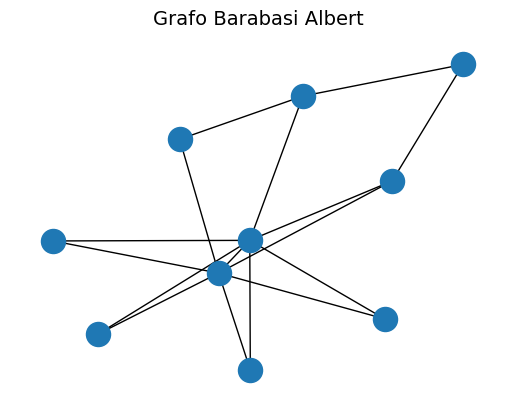

In [54]:
# n = numero de nós
# m = numero arestas
# (n, m)

B = nx.barabasi_albert_graph(10, 2)

plt.title("Grafo Barabasi Albert", fontsize=14, color="black")
nx.draw(B)

### 📊 Métricas

In [55]:
G_ba = nx.barabasi_albert_graph(100, 3, seed=42)

resultado = calcular_metricas(
    G_ba,
    modelo="Barabasi-Albert",
    seed=42
)

print(resultado)

{'modelo': 'Barabasi-Albert', 'seed': 42, 'vertices': 100, 'arestas': 291, 'grau_medio': np.float64(5.82), 'clustering': 0.18702417254401, 'densidade': 0.058787878787878785, 'transitividade': 0.09664153529814942, 'assortatividade': -0.25525500223307446, 'caminho_medio': 2.515151515151515, 'diametro': 4}


Largest connected component:
 Nós: 10, Arestas: 16


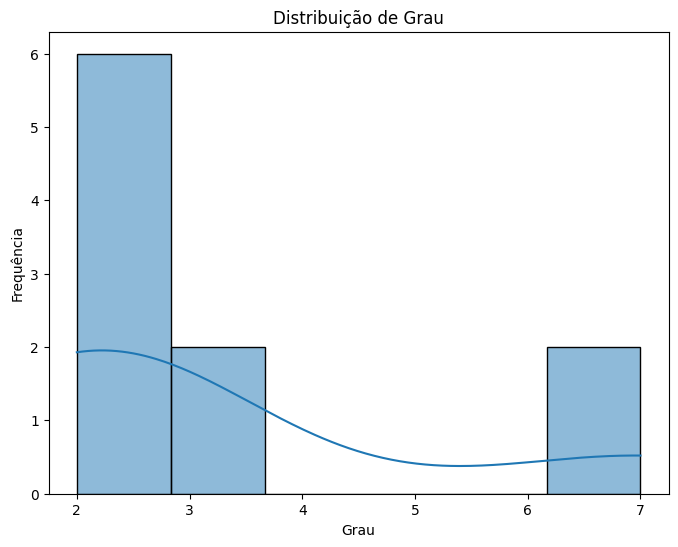

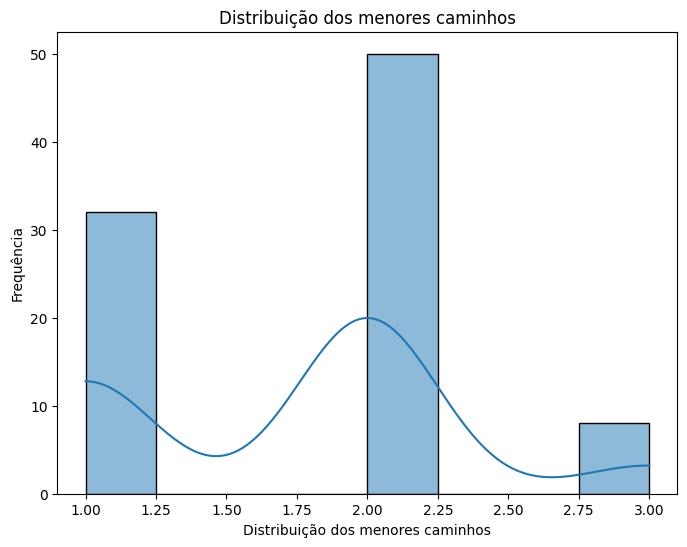



Diâmetro da Rede: 3


Top 3 nós pela Centralidade de intermediação: [(3, 0.35), (0, 0.33), (7, 0.12)]

Top 3 nós pela Centralidade de proximidade: [(0, 0.82), (3, 0.82), (7, 0.6)]

Top 3 nós pela Centralidade de grau: [(0, 0.78), (3, 0.78), (7, 0.33)]

Top 3 nodes pelo PageRank: [(0, 0.21), (3, 0.2), (8, 0.1)]


In [56]:
analyze_largest_connected_component(B)

##✳︎ | **Watts Strogatz**

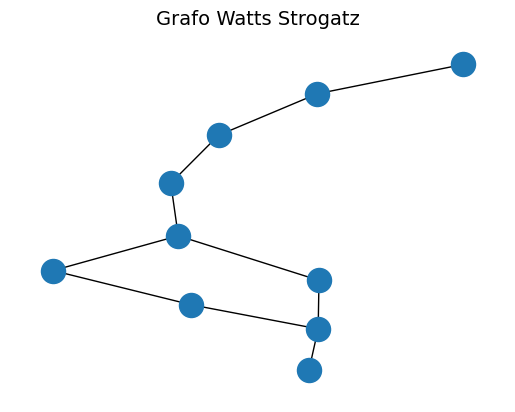

In [57]:
# n = numero de nós
# k = vizinhos
# p = probabilidade de mudar de aresta
# (n, k, p)

W = nx.watts_strogatz_graph(10, 2, 0.5)

plt.title("Grafo Watts Strogatz", fontsize=14, color="black")
nx.draw(W)

### 📊 Métricas

In [58]:
G_ws = nx.watts_strogatz_graph(100, 3, seed=42, p=0.5)

resultado = calcular_metricas(
    G_ba,
    modelo="Watts-Strogatz",
    seed=42
)

print(resultado)

{'modelo': 'Watts-Strogatz', 'seed': 42, 'vertices': 100, 'arestas': 291, 'grau_medio': np.float64(5.82), 'clustering': 0.18702417254401, 'densidade': 0.058787878787878785, 'transitividade': 0.09664153529814942, 'assortatividade': -0.25525500223307446, 'caminho_medio': 2.515151515151515, 'diametro': 4}


Largest connected component:
 Nós: 10, Arestas: 10


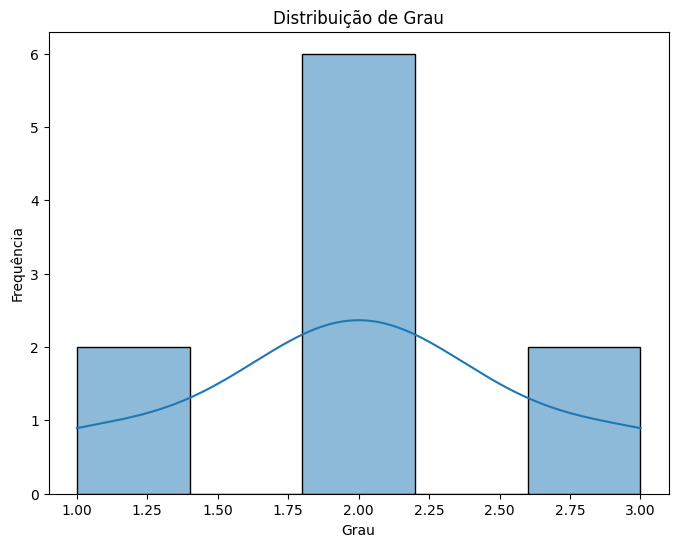

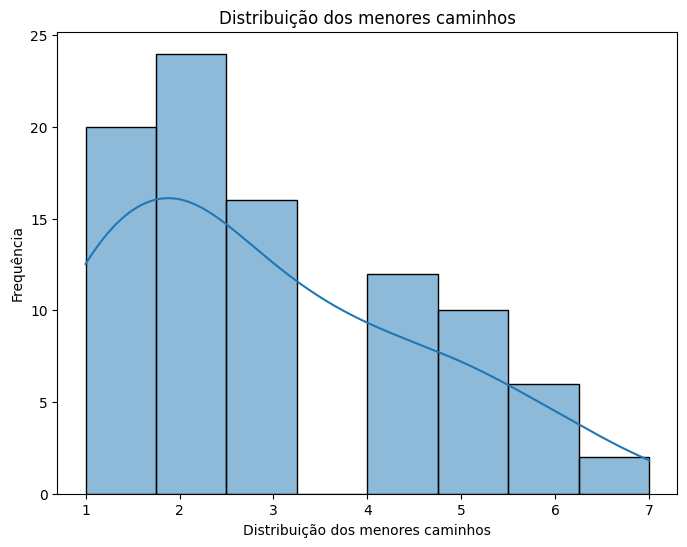



Diâmetro da Rede: 7


Top 3 nós pela Centralidade de intermediação: [(2, 0.58), (1, 0.5), (0, 0.39)]

Top 3 nós pela Centralidade de proximidade: [(2, 0.47), (1, 0.43), (6, 0.41)]

Top 3 nós pela Centralidade de grau: [(2, 0.33), (5, 0.33), (0, 0.22)]

Top 3 nodes pelo PageRank: [(5, 0.14), (2, 0.14), (9, 0.11)]


In [59]:
analyze_largest_connected_component(W)

##✳︎ |  **Erdos Renyi**

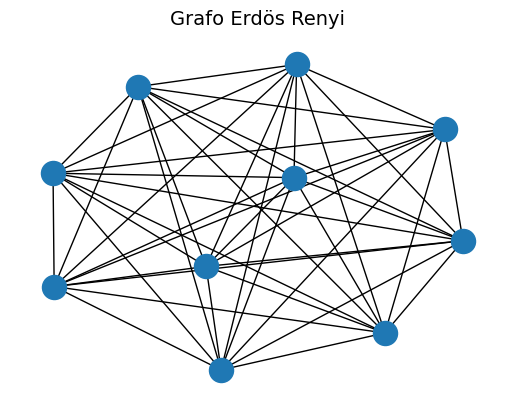

In [60]:
# n = numero de nós
# p = probabilidade de criação de arestas
# (n, p)

E = nx.erdos_renyi_graph(10, 2)

plt.title("Grafo Erdös Renyi", fontsize=14, color="black")
nx.draw(E)

### 📊 Métricas

In [61]:
G_ws = nx.erdos_renyi_graph(100, 3, seed=42)

resultado = calcular_metricas(
    G_ba,
    modelo="erdos-renyi",
    seed=42
)

print(resultado)

{'modelo': 'erdos-renyi', 'seed': 42, 'vertices': 100, 'arestas': 291, 'grau_medio': np.float64(5.82), 'clustering': 0.18702417254401, 'densidade': 0.058787878787878785, 'transitividade': 0.09664153529814942, 'assortatividade': -0.25525500223307446, 'caminho_medio': 2.515151515151515, 'diametro': 4}


Largest connected component:
 Nós: 10, Arestas: 45


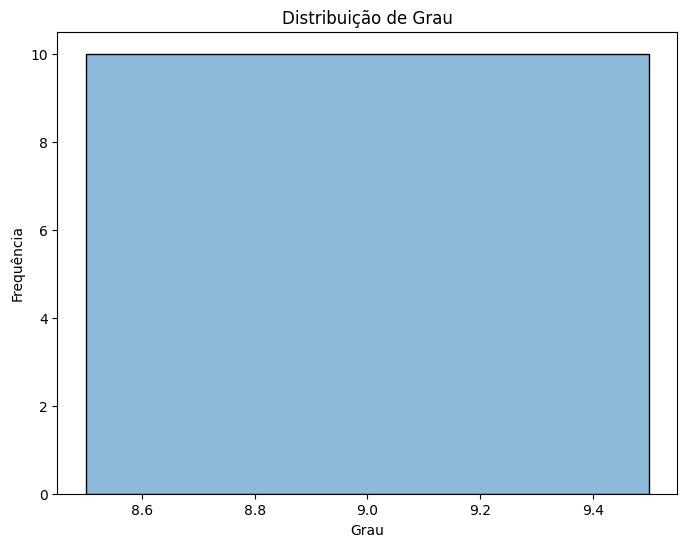

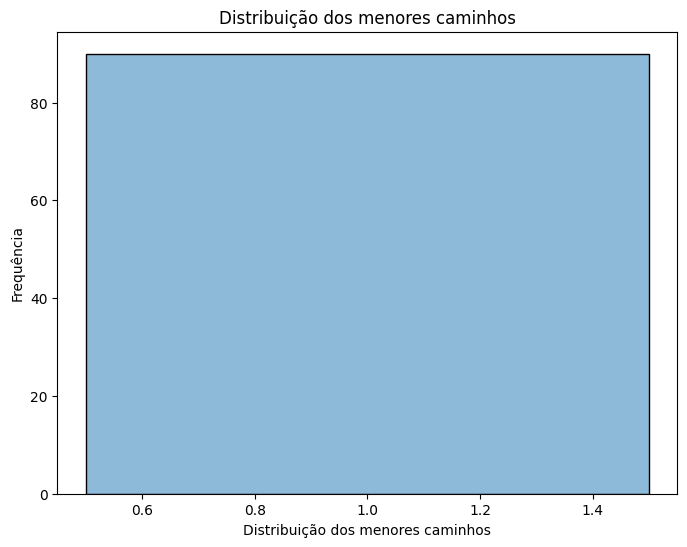



Diâmetro da Rede: 1


Top 3 nós pela Centralidade de intermediação: [(0, 0.0), (1, 0.0), (2, 0.0)]

Top 3 nós pela Centralidade de proximidade: [(0, 1.0), (1, 1.0), (2, 1.0)]

Top 3 nós pela Centralidade de grau: [(0, 1.0), (1, 1.0), (2, 1.0)]

Top 3 nodes pelo PageRank: [(0, 0.1), (1, 0.1), (2, 0.1)]


In [62]:
analyze_largest_connected_component(E)



---



# **Parte 1:**
>Vamos gerar vários grafos automaticamente e armazenar tudo em um DataFrame para que possam ser feitas análises estatísticas

Isso nos permite fazer:

* Correlações, Boxplots, Scatterplots, Testar hipóteses, Comparar modelos

In [63]:
resultados = []

Gerar grafos Barabási-Albert

In [64]:
for n in [100, 300, 500]:
  for m in [2, 4, 6]:
    for seed in range(10):
      G = nx.barabasi_albert_graph(
      n=n,
      m=m,
      seed=seed
      )

      resultados.append(
        calcular_metricas(
          G,
          modelo="Barabasi-Albert",
          seed=seed
          ))

Gerar grafos Watts-Strogatz

In [65]:
for n in [100, 300, 500]:
  for k in [4, 6, 8]:
    for p in [0.1, 0.3, 0.5, 0.8]:
      for seed in range(10):
        G = nx.watts_strogatz_graph(
          n=n,
          k=k,
          p=p,
          seed=seed)

        resultados.append(
          calcular_metricas(
            G, modelo="Watts-Strogatz", seed=seed
            ))

Gerar grafos Erdős-Rényi

In [66]:
for n in [100, 300, 500]:
  for p in [0.01, 0.03, 0.05, 0.1]:
    for seed in range(10):
      G = nx.erdos_renyi_graph(
        n=n,
        p=p,
        seed=seed)

      resultados.append(
        calcular_metricas(
          G, modelo="Erdos-Renyi", seed=seed
          ))

Criando dataframe

In [67]:
df = pd.DataFrame(resultados)

In [68]:
df.shape

(570, 11)

## **QUESTÕES:**

### **| Questão 1: Qual modelo de rede apresenta maior clustering coefficient?**

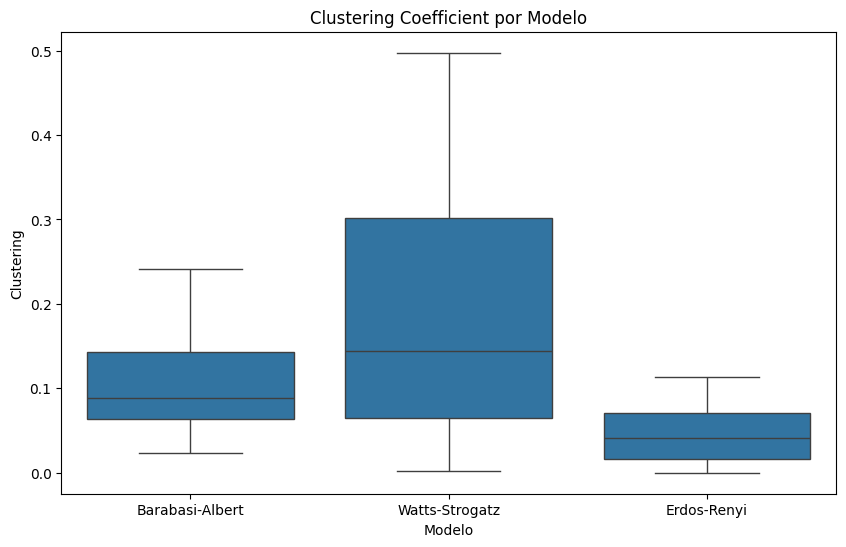

In [69]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="modelo",
    y="clustering"
)

plt.title("Clustering Coefficient por Modelo")
plt.xlabel("Modelo")
plt.ylabel("Clustering")
plt.show()

A análise do clustering coefficient mostrou diferenças significativas entre os modelos. As redes Watts-Strogatz apresentaram os maiores valores medianos de clustering, indicando maior formação de comunidades locais. As redes Erdős-Rényi apresentaram os menores valores, comportamento esperado devido à natureza aleatória das conexões. As redes Barabási-Albert ficaram em uma posição intermediária. Esses resultados sugerem que o modelo Watts-Strogatz é o mais propenso à criação de agrupamentos locais entre vértices.

### **| Questão 2: Redes livres de escala tendem a ser dissortativas? (Barabási-Albert)**
<BR>

**HIPÓTESE:**

Redes Barabási-Albert tendem a apresentar assortatividade negativa.

Isso ocorre porque hubs se conectam a muitos nós pequenos.

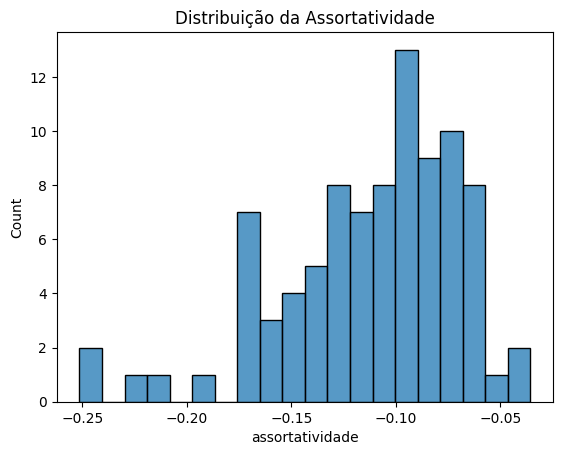

In [70]:
ba = df[df["modelo"] == "Barabasi-Albert"]

sns.histplot(
    ba["assortatividade"],
    bins=20
)

plt.title("Distribuição da Assortatividade")
plt.show()

In [71]:
media = ba["assortatividade"].mean().round(2)
print(f"Média: {media}")

Média: -0.11


A hipótese foi confirmada pelos resultados obtidos. Observou-se que todos os grafos Barabási-Albert apresentaram valores negativos de assortatividade, concentrados principalmente entre -0,15 e -0,07. Isso indica que a rede tende a ser dissortativa, ou seja, vértices com alto grau tendem a se conectar com vértices de baixo grau. Esse comportamento é esperado em redes livres de escala, pois poucos hubs concentram muitas conexões enquanto a maioria dos vértices possui baixo grau.

A assortatividade média observada foi de -0.11, reforçando a característica dissortativa das redes Barabási-Albert.

### **| Questão 3: Qual modelo apresenta menores caminhos médios?**
<BR>

**HIPÓTESE:**

Redes Barabási-Albert tendem a apresentar caminhos médios menores devido à presença de hubs que conectam rapidamente diferentes partes da rede.

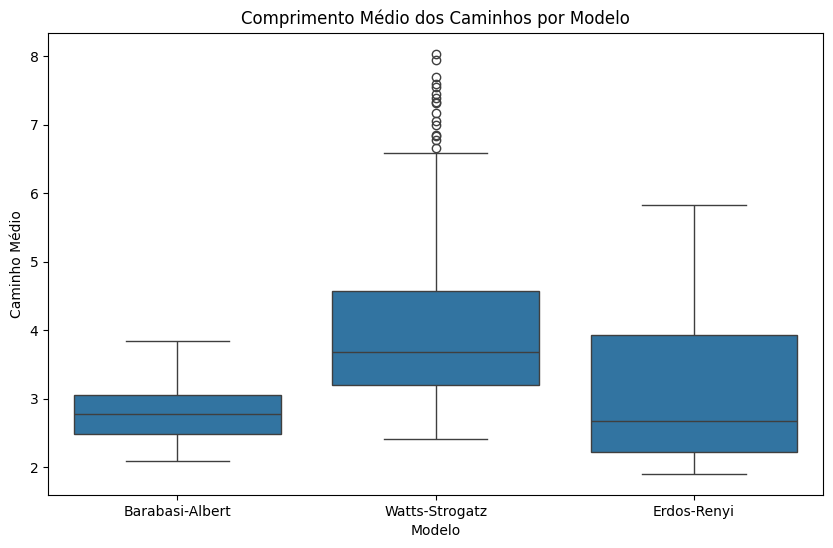

In [72]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="modelo",
    y="caminho_medio"
)

plt.title("Comprimento Médio dos Caminhos por Modelo")
plt.xlabel("Modelo")
plt.ylabel("Caminho Médio")

plt.show()

Os resultados indicam que as redes Barabási-Albert apresentam menores comprimentos médios de caminho. A presença de hubs cria atalhos entre diferentes regiões da rede, reduzindo o número médio de passos necessários para conectar dois vértices.

PLOT GERAL COM A DISTRIBUIÇÃO DAS MÉTRICAS

<Axes: xlabel='modelo', ylabel='clustering'>

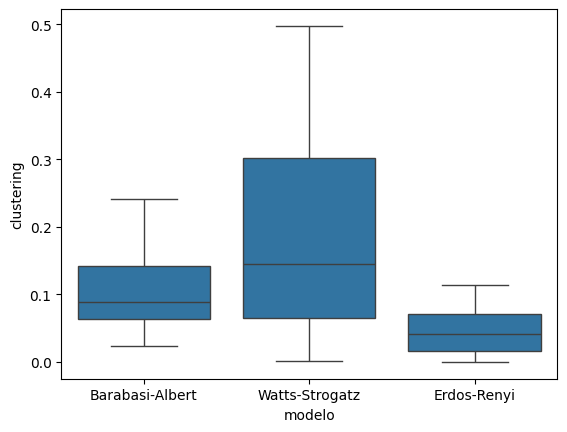

In [73]:
sns.boxplot(data=df, x="modelo", y="clustering")

<Axes: xlabel='modelo', ylabel='diametro'>

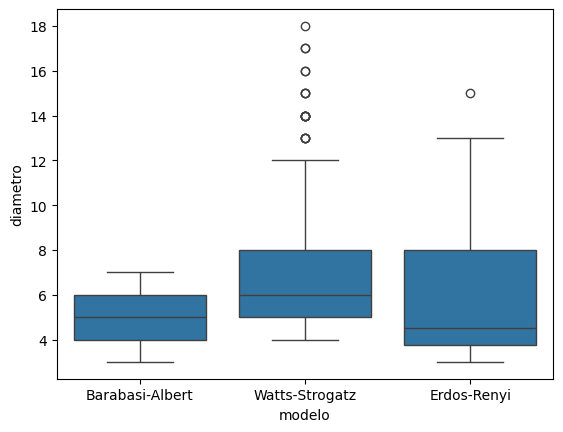

In [74]:
sns.boxplot(data=df, x="modelo", y="diametro")

<Axes: xlabel='modelo', ylabel='caminho_medio'>

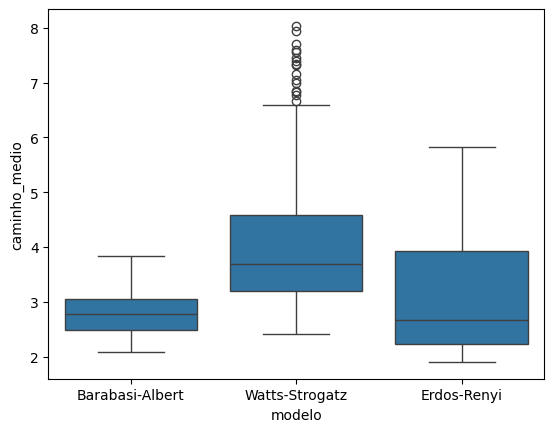

In [75]:
sns.boxplot(data=df, x="modelo", y="caminho_medio")

<Axes: xlabel='modelo', ylabel='assortatividade'>

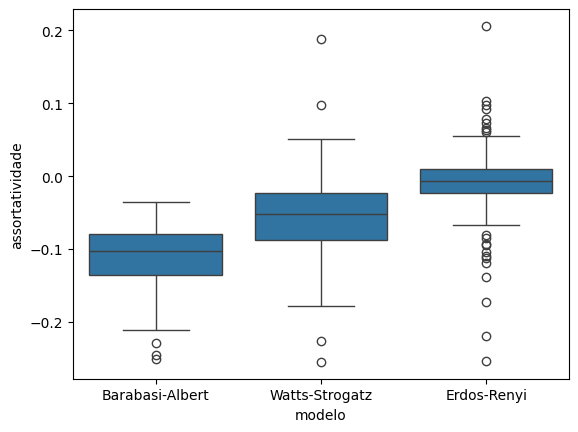

In [76]:
sns.boxplot(data=df, x="modelo", y="assortatividade")

### **Distribuição das métricas**

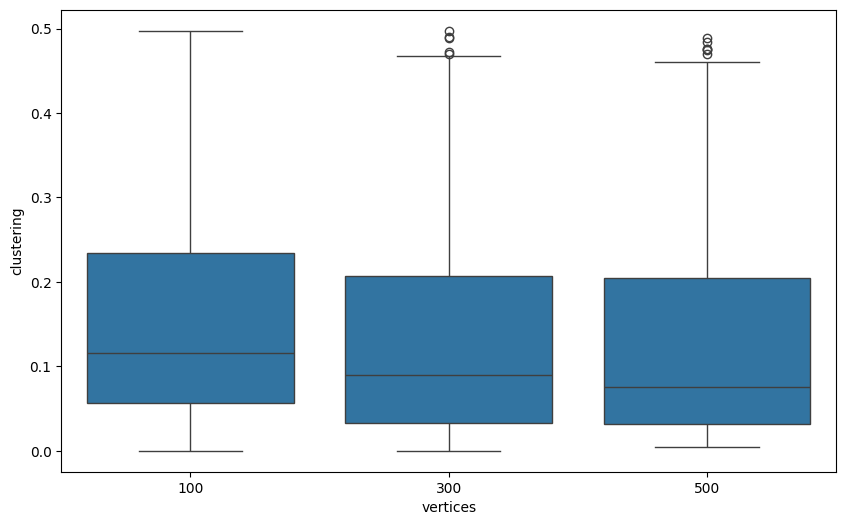

In [79]:
# Clustering × número de vértices

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="vertices",
    y="clustering"
)

plt.show()

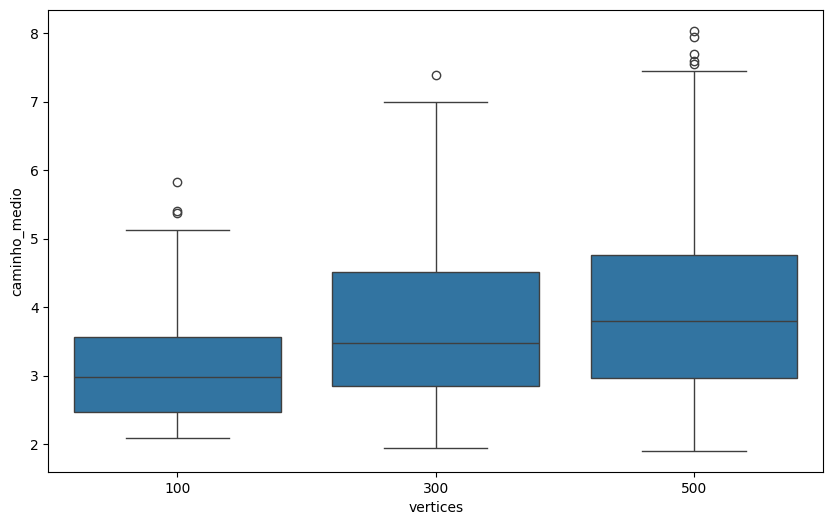

In [80]:
# Caminho médio × número de vértices

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="vertices",
    y="caminho_medio"
)

plt.show()



---



# **Parte 2:**

In [81]:
G_real = nx.read_weighted_edgelist(
    "/content/bio-CE-GN.edges",
    nodetype=int
)

In [82]:
n = G_real.number_of_nodes()
m_real = G_real.number_of_edges()

grau_medio = (2 * m_real) / n

print(f"Nós: {n}")
print(f"Arestas: {m_real}")
print(f"Grau médio: {grau_medio:.2f}")

Nós: 2220
Arestas: 53683
Grau médio: 48.36


In [83]:
# CALCULANDO AS MÉTRICAS DO GRAFO REAL
metricas_real = calcular_metricas(
    G_real,
    modelo="Grafo Real"
)

metricas_real

{'modelo': 'Grafo Real',
 'seed': None,
 'vertices': 2220,
 'arestas': 53683,
 'grau_medio': np.float64(48.363063063063066),
 'clustering': 0.18387705377947847,
 'densidade': 0.021794981100974792,
 'transitividade': 0.1390160997363684,
 'assortatividade': 0.0683705996860557,
 'caminho_medio': 2.6984047748679143,
 'diametro': 7}

### **Criando grafos sintéticos equivalentes**

In [84]:
# Barabási-Albert
m_ba = max(1, round(grau_medio / 2))

G_ba_eq = nx.barabasi_albert_graph(
    n=n,
    m=m_ba,
    seed=42
)

In [85]:
# Erdős-Rényi
p_er = (2 * m_real) / (n * (n - 1))

G_er_eq = nx.erdos_renyi_graph(
    n=n,
    p=p_er,
    seed=42
)

In [86]:
# Watts-Strogatz
k_ws = round(grau_medio)

if k_ws % 2 != 0:
    k_ws += 1

G_ws_eq = nx.watts_strogatz_graph(
    n=n,
    k=k_ws,
    p=0.1,
    seed=42
)

### **Comparando métricas**

In [87]:
comparacao = pd.DataFrame([
    calcular_metricas(G_real, "Real"),
    calcular_metricas(G_ba_eq, "Barabasi-Albert"),
    calcular_metricas(G_ws_eq, "Watts-Strogatz"),
    calcular_metricas(G_er_eq, "Erdos-Renyi")
])

comparacao

,modelo,seed,vertices,arestas,grau_medio,clustering,densidade,transitividade,assortatividade,caminho_medio,diametro
0,Real,None,2220,53683,48.363063,0.183877,0.021795,0.139016,0.068371,2.698405,7
1,Barabasi-Albert,None,2220,52704,47.481081,0.061087,0.021398,0.059524,-0.009085,2.292347,3
2,Watts-Strogatz,None,2220,53280,48.000000,0.535341,0.021631,0.533472,-0.000412,2.760209,4
3,Erdos-Renyi,None,2220,53851,48.514414,0.021809,0.021863,0.021789,-0.006660,2.316419,3


### **Fazendo um gráfico comparativo**

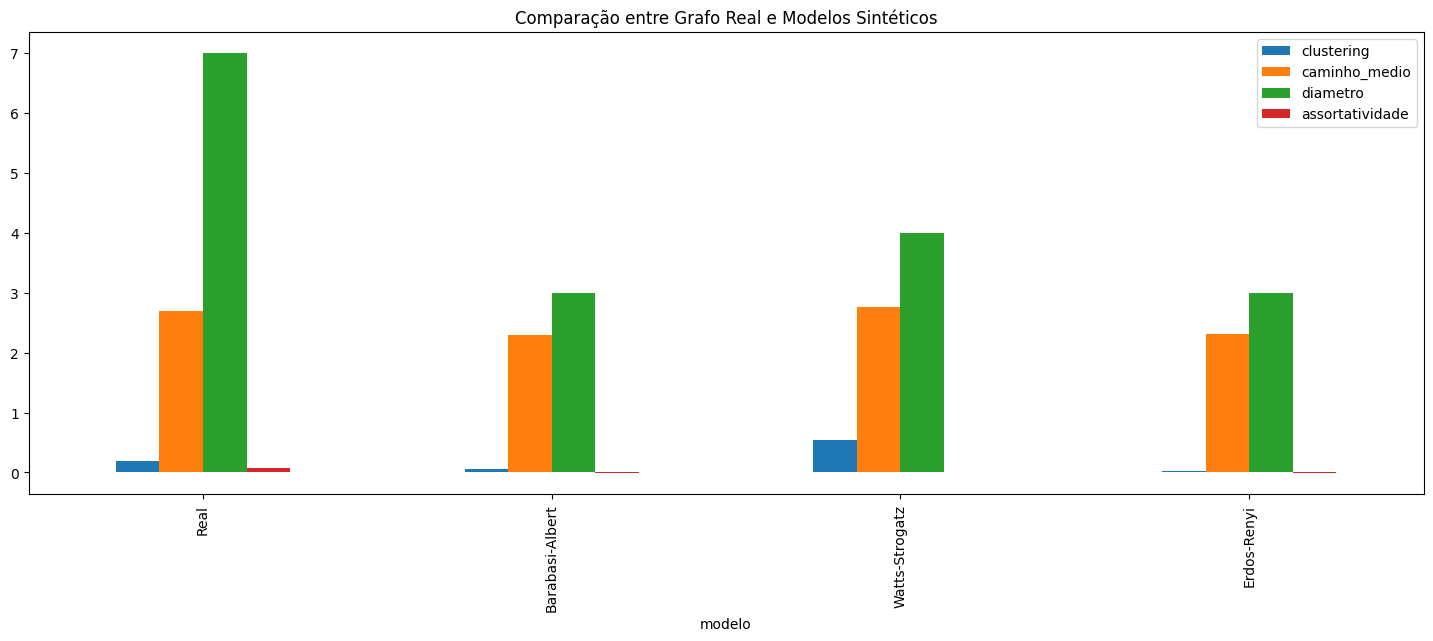

In [88]:
metricas = [
    "clustering",
    "caminho_medio",
    "diametro",
    "assortatividade"
]

comparacao.set_index("modelo")[metricas].plot(
    kind="bar",
    figsize=(18,6)
)

plt.title("Comparação entre Grafo Real e Modelos Sintéticos")
plt.show()

### **Verificando se é de livre escala**

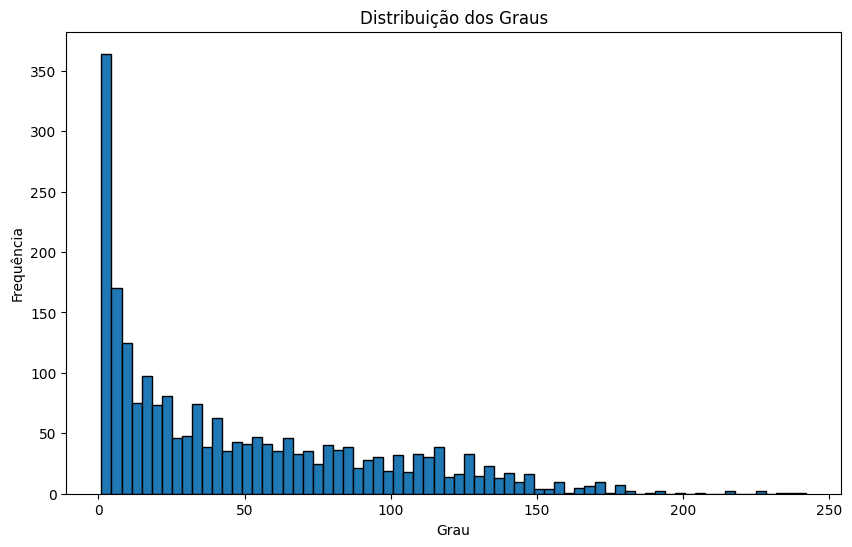

In [89]:
graus = [d for _, d in G_real.degree()]

plt.figure(figsize=(10,6))

plt.hist(
    graus,
    bins=70,
    edgecolor='black'
)

plt.title("Distribuição dos Graus")
plt.xlabel("Grau")
plt.ylabel("Frequência")

plt.show()

* A maior parte dos nós tem grau baixo
> As barras altas estão concentradas perto do zero (graus pequenos).

* Poucos nós têm grau muito alto
> Existe uma cauda longa se estendendo até valores acima de 200.

Isso é uma forte evidência de rede livre escala

### **Encontrando os 3 vértices mais importantes**

In [90]:
bet = nx.betweenness_centrality(G_real)

top3 = sorted(
    bet.items(),
    key=lambda x: x[1],
    reverse=True
)[:3]

top3_df = pd.DataFrame(
    top3,
    columns=["Vértice", "Betweenness"]
)

top3_df

,Vértice,Betweenness
0,357,0.019527
1,192,0.013280
2,146,0.012791


❗Um vértice é importante se ele se relaciona à muitos outros.
<br><br>

Os vértices **357, 192 e 146** apresentaram os maiores valores de betweenness centrality. Essa métrica mede quantos caminhos mínimos da rede passam por um determinado vértice.

Portanto, esses nós atuam como importantes intermediários na comunicação da rede, facilitando a conexão entre diferentes regiões do grafo.

A remoção desses vértices teria potencial para aumentar as distâncias entre os nós ou até fragmentar partes da rede.



---



### **1. O grafo parece livre de escala, small world ou aleatório?**
O grafo apresenta características de uma rede **livre de escala**. A distribuição dos graus mostra muitos vértices com poucas conexões e poucos vértices altamente conectados (hubs). Esse comportamento é típico de redes livres de escala geradas por mecanismos de crescimento preferencial.
<br><br>

**EVIDÊNCIAS:**

No histograma de graus existem:
* muitos nós com grau baixo;
* poucos nós com grau extremamente alto (hubs).

O clustering do grafo real (0.184) é muito mais próximo do Barabási-Albert (0.061) do que do Erdős-Rényi (0.022), embora seja ainda maior.
<br><br>

---
<br>

O grafo também apresenta características de uma rede **small world**. Apesar do grande número de vértices, o comprimento médio dos caminhos é de apenas 2,70 passos, indicando que qualquer vértice pode ser alcançado rapidamente. Além disso, o clustering coefficient é significativamente maior do que o observado em uma rede aleatória.
<br><br>

---
<br>

O grafo **não é uma rede aleatória**. Redes Erdős-Rényi apresentam clustering muito baixo e distribuição de graus mais homogênea. O grafo analisado apresenta maior agrupamento local e presença de hubs, características incompatíveis com uma rede puramente aleatória.

### **2. Quais os 3 vértices mais importantes?**

Os vértices 357, 192 e 146 foram identificados como os mais importantes da rede por apresentarem os maiores valores de betweenness centrality.

Essa métrica mede a frequência com que um vértice aparece nos menores caminhos entre pares de vértices. Portanto, esses nós desempenham papel fundamental na comunicação e integração da rede.

### **3. Essa rede tende a ser robusta a falhas?**

A rede tende a ser robusta a falhas aleatórias. Como a maioria dos vértices possui baixo grau, a remoção aleatória de nós tem baixa probabilidade de atingir os hubs responsáveis pela conectividade global da rede.


Por outro lado, a remoção direcionada dos hubs mais importantes pode causar forte degradação da conectividade da rede, fragmentando-a em componentes menores.

### **4. A difusão de informação é fácil?**

A difusão de informação é facilitada pela estrutura da rede. O caminho médio de apenas 2,70 indica que a informação pode atingir rapidamente qualquer região da rede. O diâmetro igual a 7 também sugere que mesmo os vértices mais distantes encontram-se relativamente próximos.

### **5. A preservação da informação é fácil?**

A preservação da informação tende a ser favorecida pela presença de agrupamentos locais. O valor relativamente elevado do clustering coefficient indica a existência de múltiplos caminhos alternativos entre vértices vizinhos, reduzindo a dependência de conexões únicas.

### **6. É fácil navegar nessa rede?**

A navegação na rede é relativamente simples devido à presença de hubs altamente conectados. Esses vértices funcionam como atalhos estruturais, reduzindo a quantidade de passos necessária para alcançar regiões distantes da rede.


### **CONCLUSÃO FINAL**

O grafo analisado apresenta características típicas de redes livres de escala e small world. A distribuição dos graus evidencia a presença de hubs, enquanto o baixo caminho médio (2,70) e o clustering coefficient relativamente elevado (0,184) indicam forte conectividade local combinada com curtas distâncias globais. Os vértices 357, 192 e 146 destacam-se como os mais importantes segundo a métrica de betweenness centrality. A rede tende a ser robusta a falhas aleatórias, embora vulnerável à remoção direcionada de hubs. Além disso, apresenta condições favoráveis para difusão, preservação e navegação da informação